In [ ]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v25.dream_cytof.EGFR_MAPK")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "par_median_frob_norm", "par_dev_frob_norm", "_step"]
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
                # Frobenius norms of medians and deviations
                "par_median_frob_norm": row["par_median_frob_norm"],
                "par_dev_frob_norm": row["par_dev_frob_norm"],
            })

results_df = pd.DataFrame(all_rows)

In [ ]:
results_df.to_csv("results_05062025_Fabian.csv", index=False)

# Restart from here

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
results_df = pd.read_csv("results_05062025_Fabian.csv")
baseline_df = pd.read_csv("baseline_performance/baseline_regressors_rmse_newcv_newselect.csv")

# Subset to `features` used for scans

In [2]:
results_df = results_df[
    ((results_df.context == "cytof_init") & (results_df.features == "RFE_10_permute")) |
    ((results_df.context == "proteomics") & (results_df.features == "HVGRFE_20_permute")) |
    ((results_df.context == "transcriptomics") & (results_df.features.isin(["HVGRFE_15_permute", "HVGRFE_20_permute"])))
]

In [3]:
results_df.sort_values(by=["context", "samples", "features", "features_selection", "l1reg_inflater_output", "l2reg_inflater_output", "job", "step"], inplace=True)
baseline_df.sort_values(by=["context", "features", "features_selection", "dataset"], inplace=True)

In [4]:
def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

## Scan 1 - `l2reg_inflater_output` (`l1reg_inflater_output` == 1e3)

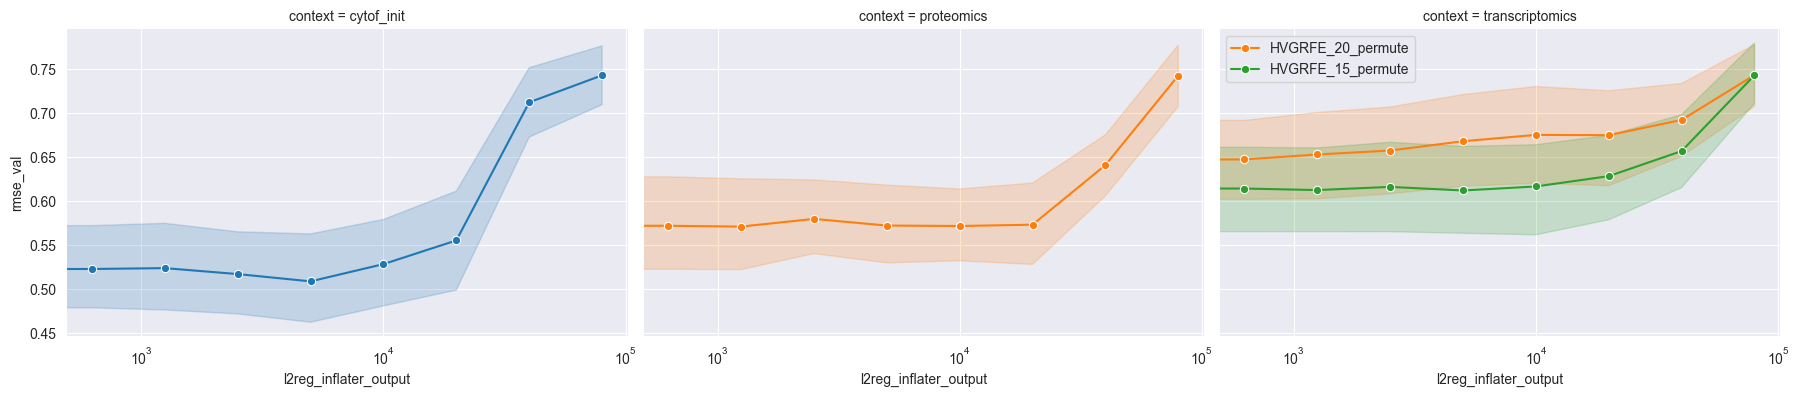

In [5]:
# Subset to final epoch (499) and l1reg_inflater_output == 1000 (central value for L2 reg scan)
l2reg_scan = results_df[(results_df.l1reg_inflater_output == 1000) & (results_df.step == results_df.step.max())]

g = sns.FacetGrid(
    l2reg_scan,
    col="context",
    col_order=sorted(l2reg_scan["context"].unique()),
    hue="features",
    hue_order=l2reg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l2reg_inflater_output",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("log")
plt.legend()

Show trend across all `samples` -- almost perfectly consistent, apart from `transcriptomics` `3of5`.

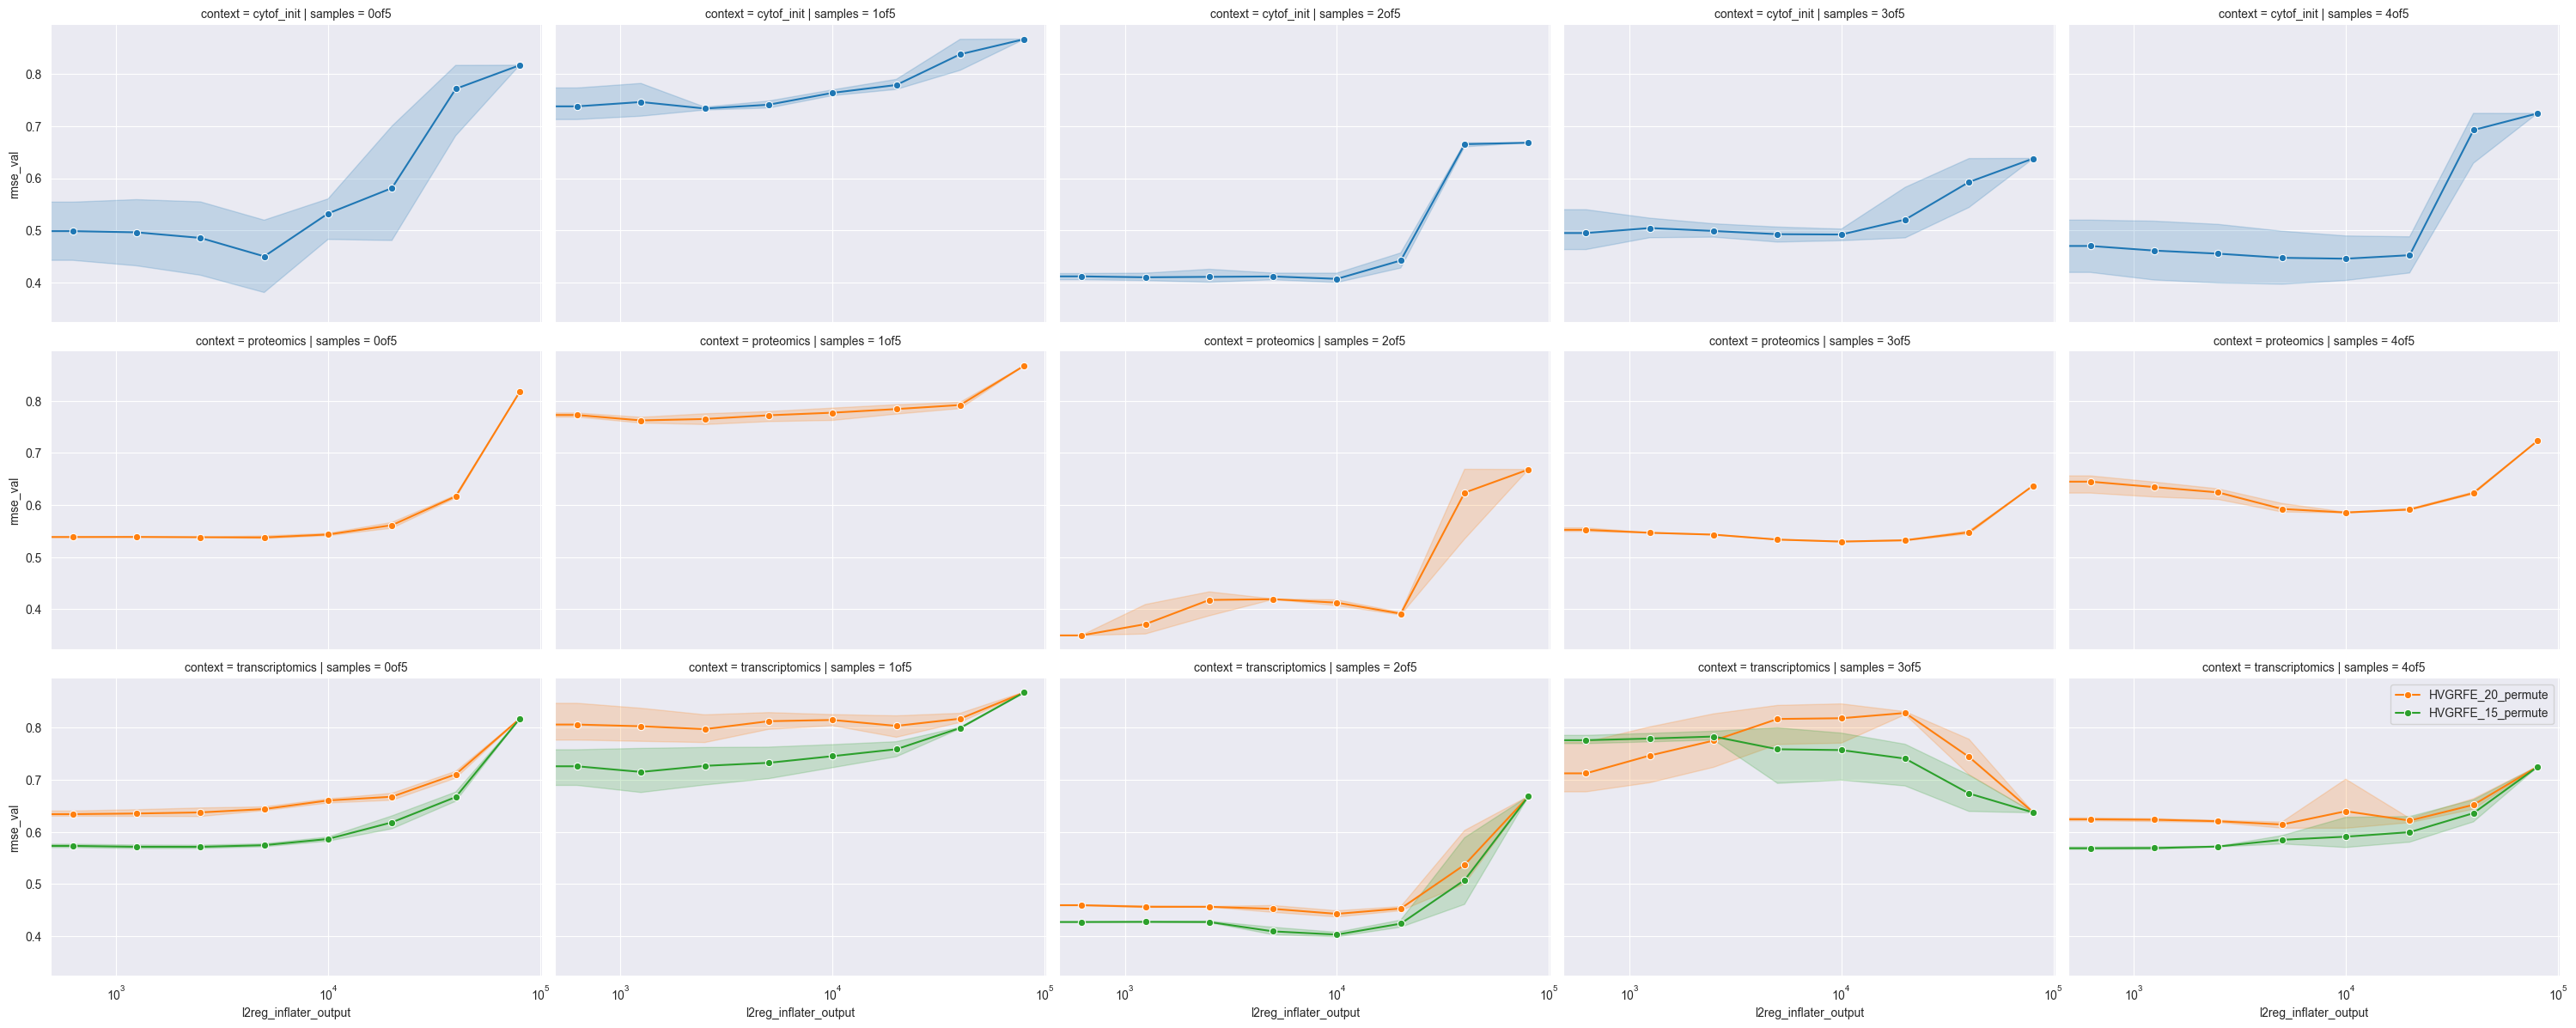

In [7]:
g = sns.FacetGrid(
    l2reg_scan,
    row="context",
    row_order=sorted(l2reg_scan["context"].unique()),
    col="samples",
    col_order=sorted(l2reg_scan["samples"].unique()),
    hue="features",
    hue_order=l2reg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l2reg_inflater_output",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("log")
plt.legend()

Is there a statistically better `features` for `transcriptomics`? Yes, there is a statistically significant difference between `HVGRFE_15_permute` and `HVGRFE_20_permute` for `transcriptomics` context! (p-value < 0.05)

In [8]:
import scipy.stats as stats
kruskal_wallis_groups(
    l2reg_scan[l2reg_scan.context == "transcriptomics"],
    target_metric="rmse_val",
    group_metric="features"
)

Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=16.20, p-value=0.0001


<Axes: xlabel='l2reg_inflater_output', ylabel='rmse_val'>

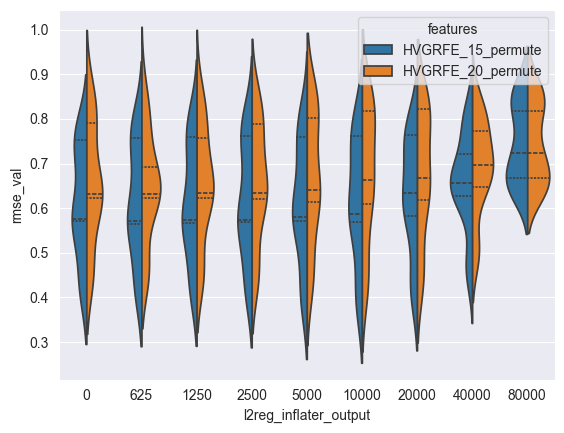

In [9]:
sns.violinplot(
    data=l2reg_scan[l2reg_scan.context == "transcriptomics"],
    x="l2reg_inflater_output",
    y="rmse_val",
    hue="features",
    split=True,
    inner="quartile",
    palette="tab10"
)

Is there any statistically better value of `l2reg_inflater_output` for each `context`? Clearly yes, but which one is it?

In [10]:
import scipy.stats as stats
kruskal_wallis_groups(
    l2reg_scan,
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=65.81, p-value=0.0000
Context: proteomics - Kruskal-Wallis H-test: H-statistic=45.07, p-value=0.0000
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=37.35, p-value=0.0000


# Scan 2 - `l1reg_inflater_output` with 2 options for `l2reg_inflater_output` (0, 1e4)

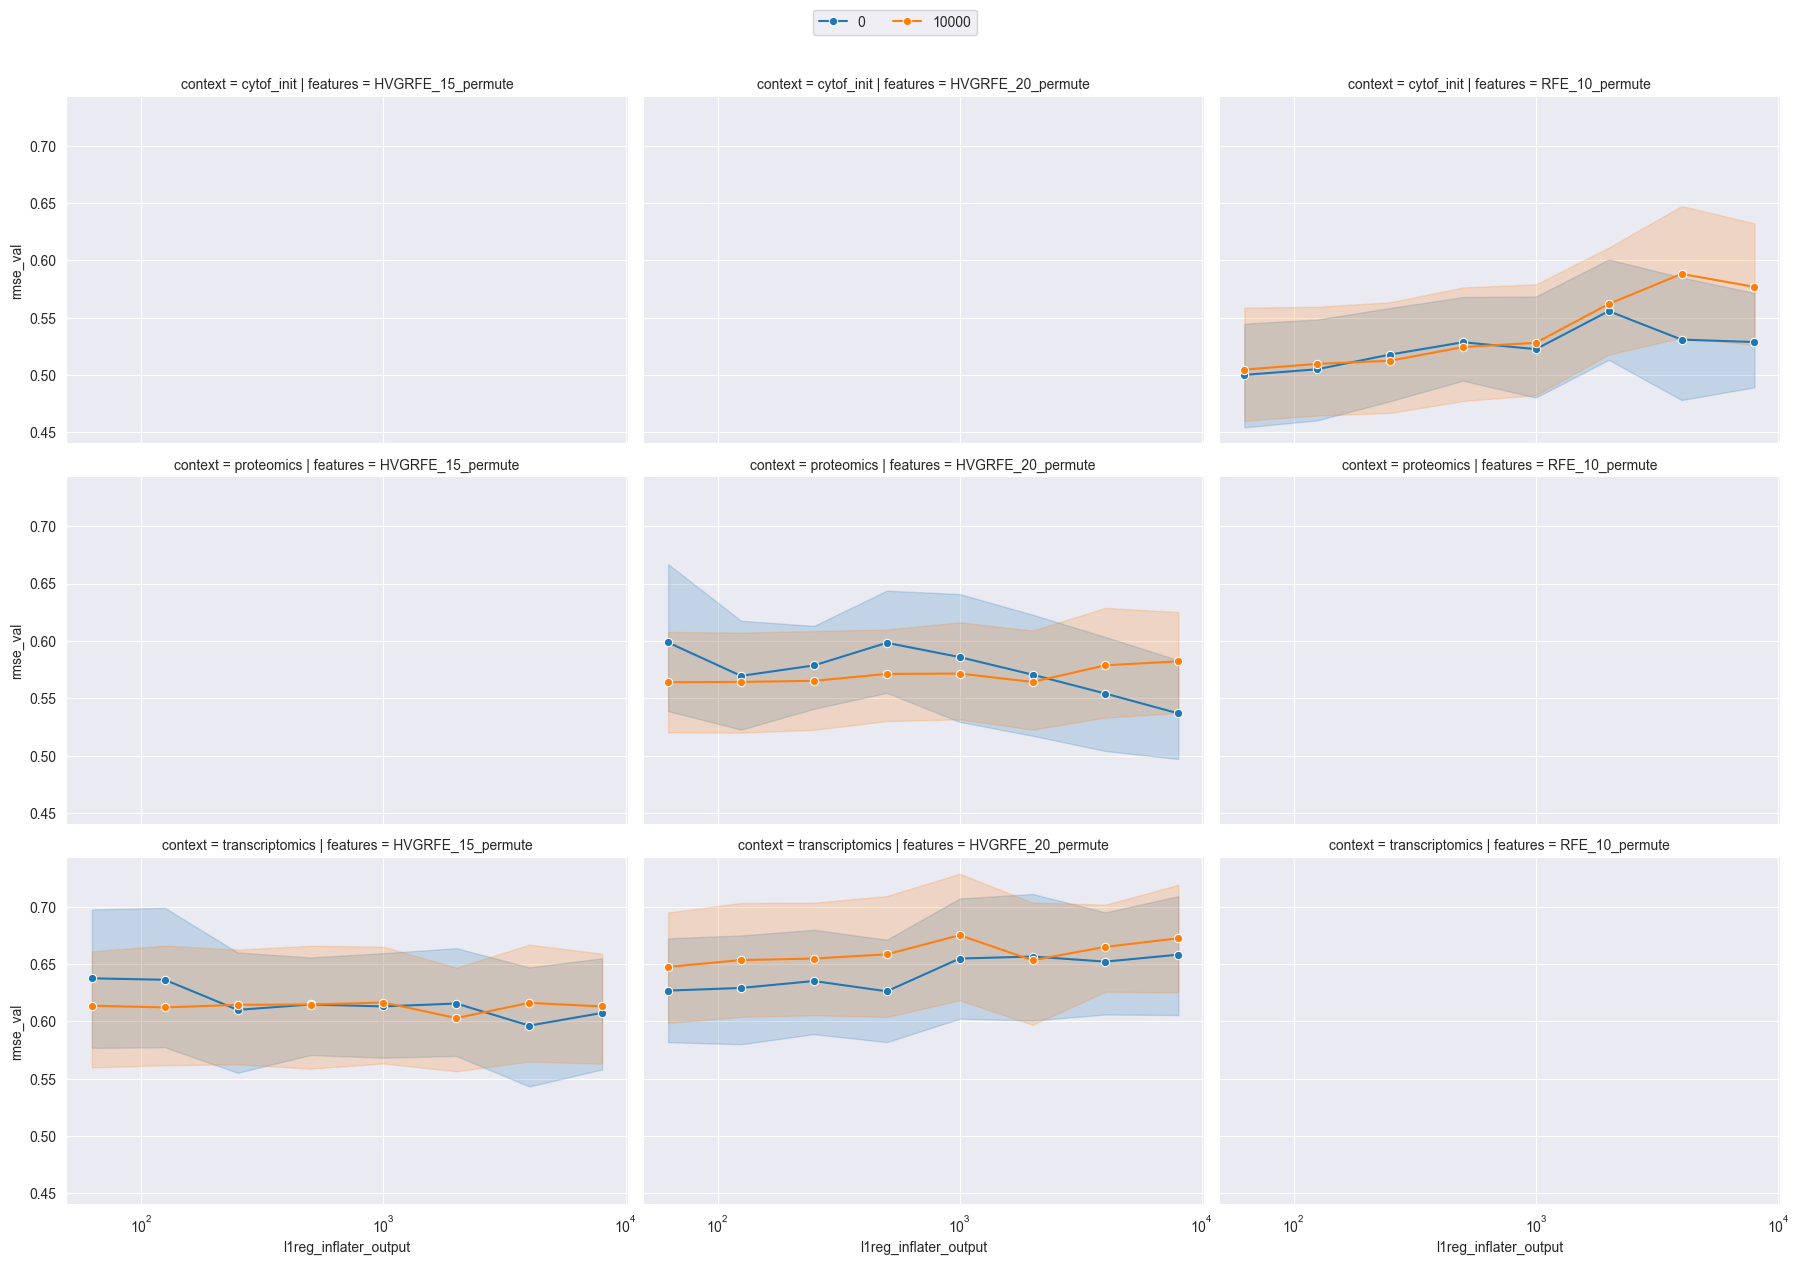

In [11]:
l1reg_scan = results_df[(results_df.l2reg_inflater_output.isin([0, 1e4])) & (results_df.step == results_df.step.max())]

g = sns.FacetGrid(
    l1reg_scan,
    col="features",
    col_order=sorted(l1reg_scan["features"].unique()),
    row="context",
    row_order=sorted(l1reg_scan["context"].unique()),
    hue="l2reg_inflater_output",
    hue_order=sorted(l1reg_scan.l2reg_inflater_output.unique()),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l1reg_inflater_output",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("log")

# Find an axis with data and draw the legend from that
for ax in g.axes.flat:
    if len(ax.lines) > 0:
        handles, labels = ax.get_legend_handles_labels()
        g._legend = g.figure.legend(
            handles, labels,
            loc='upper center', ncol=len(labels),
            bbox_to_anchor=(0.5, 1.05)
        )
        break

Is there a difference between not using and using `l2reg_inflater_output` in each context? Not in `cytof_init` or `proteomics`, either if looking at all values or only those above 2000. Not even in `transcriptomics`, for either `features`. If anything, the lowest values are achieved with no `l2reg_inflater_output` in all cases.

In [12]:
kruskal_wallis_groups(
    l1reg_scan[l1reg_scan.context == "cytof_init"],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "cytof_init") & (l1reg_scan.l1reg_inflater_output > 2000)],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.14, p-value=0.7080
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=3.52, p-value=0.0608


In [13]:
kruskal_wallis_groups(
    l1reg_scan[l1reg_scan.context == "proteomics"],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "proteomics") & (l1reg_scan.l1reg_inflater_output > 2000)],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: proteomics - Kruskal-Wallis H-test: H-statistic=0.47, p-value=0.4942
Context: proteomics - Kruskal-Wallis H-test: H-statistic=3.26, p-value=0.0709


In [14]:
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "transcriptomics") & (l1reg_scan.features == "HVGRFE_15_permute")],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "transcriptomics") & (l1reg_scan.features == "HVGRFE_20_permute")],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9311
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=1.64, p-value=0.2002


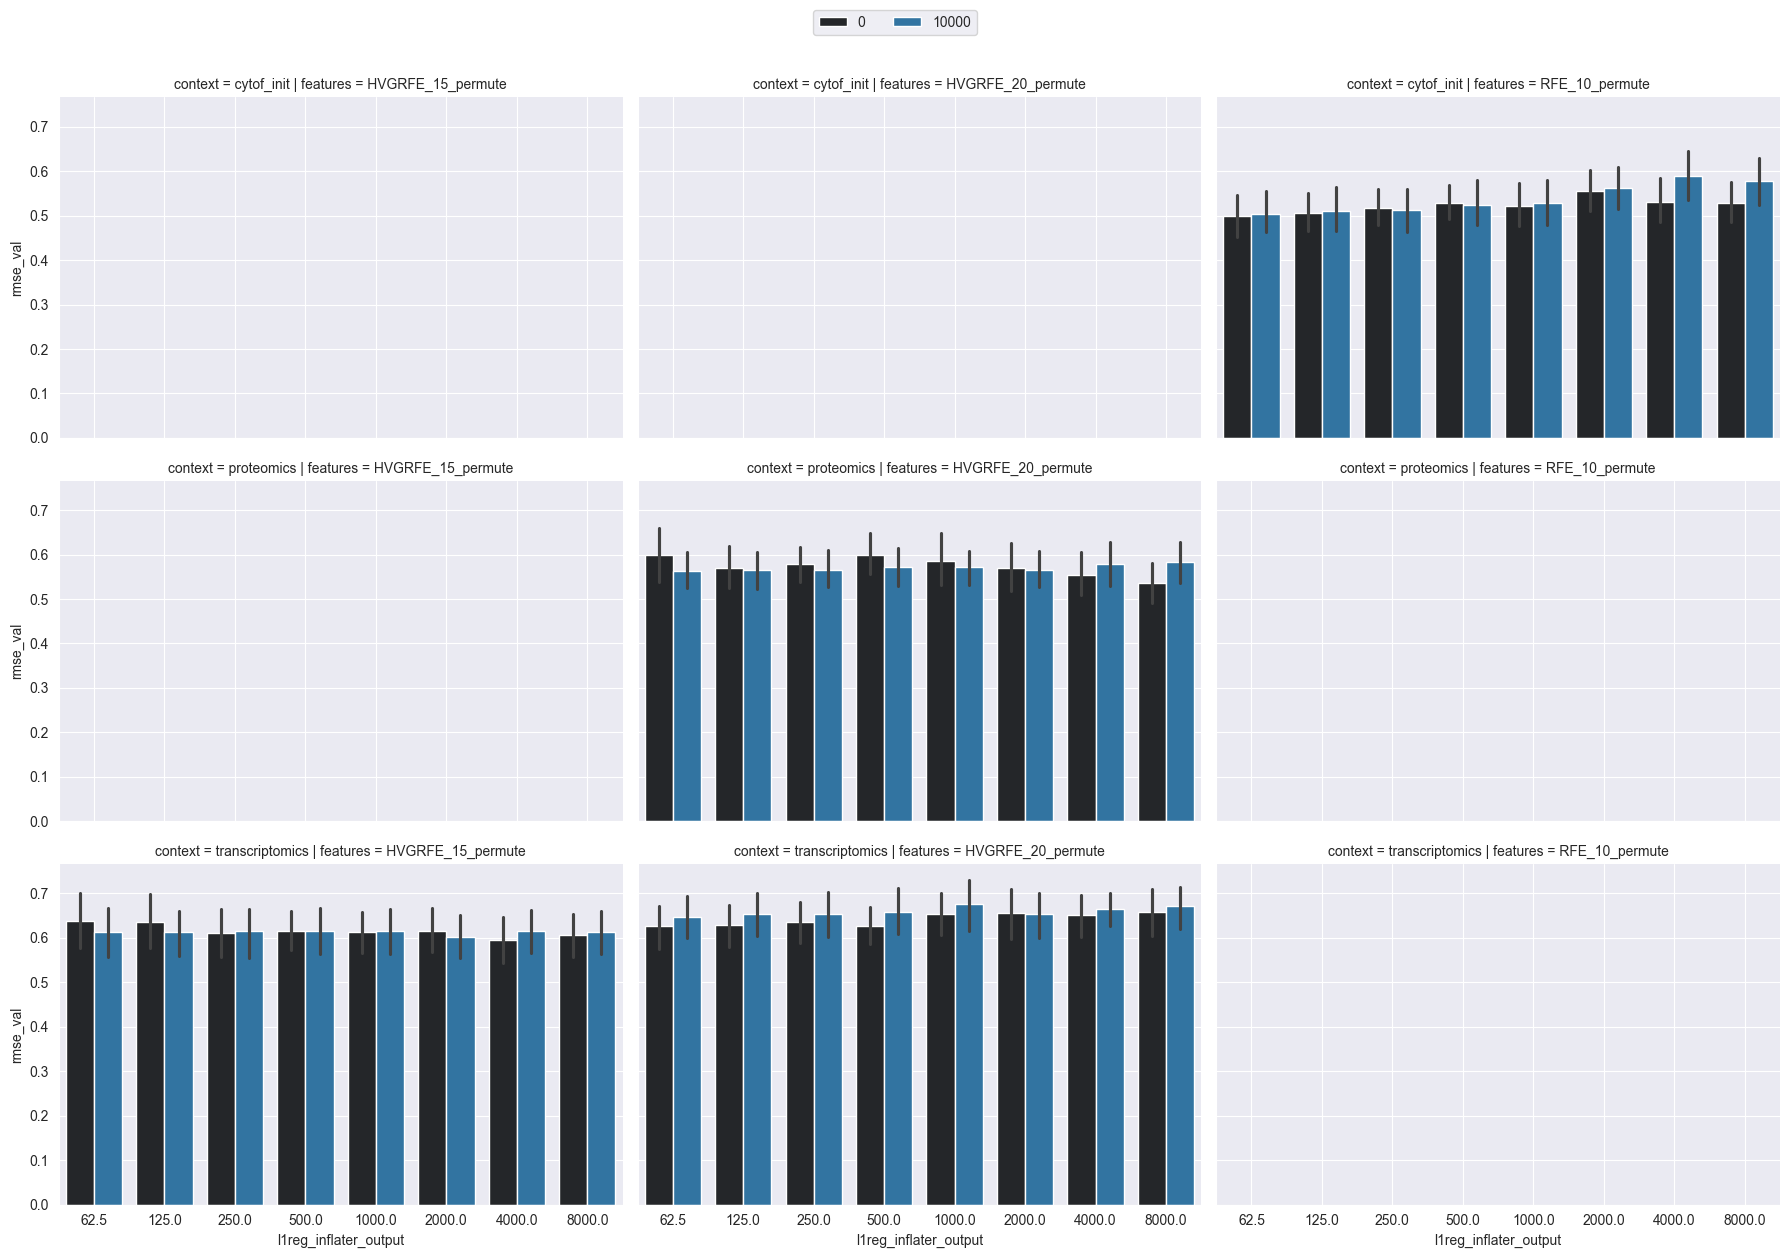

In [17]:
g = sns.FacetGrid(
    l1reg_scan,
    row="context",
    row_order=sorted(l1reg_scan["context"].unique()),
    col="features",
    col_order=sorted(l1reg_scan["features"].unique()),
    height=4,
    aspect=1.5
)

g.map_dataframe(
    sns.barplot,
    x="l1reg_inflater_output",
    y="rmse_val",
    hue="l2reg_inflater_output",
    hue_order=sorted(l1reg_scan.l2reg_inflater_output.unique()),
    #split=True,
)

# Find an axis with data and draw the legend from that
for ax in g.axes.flat:
    if len(ax.lines) > 0:
        handles, labels = ax.get_legend_handles_labels()
        g._legend = g.figure.legend(
            handles, labels,
            loc='upper center', ncol=len(labels),
            bbox_to_anchor=(0.5, 1.05)
        )
        break


The best options seem to be: 62.5 `l1` and 0 `l2` for `cytof_init`, 8000 `l1` and 0 `l2` for `proteomics`, and 4000 `l1` and 0 `l2` for `transcriptomics` with `HVGRFE_15_permute` `features`.

In [22]:
agg_rmse = (
    l1reg_scan
    .groupby(['context', 'features', 'l1reg_inflater_output', 'l2reg_inflater_output'])['rmse_val']
    .mean()
    .reset_index()
)

best_combos = (
    agg_rmse
    .groupby(['context', 'features'])
    .apply(lambda df: df.loc[df['rmse_val'].idxmin()])
    .reset_index(drop=True)
)

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_90472/3584228608.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.loc[df['rmse_val'].idxmin()])


In [23]:
best_combos

,context,features,l1reg_inflater_output,l2reg_inflater_output,rmse_val
0,cytof_init,RFE_10_permute,62.5,0,0.500144
1,proteomics,HVGRFE_20_permute,8000.0,0,0.536806
2,transcriptomics,HVGRFE_15_permute,4000.0,0,0.596328
3,transcriptomics,HVGRFE_20_permute,500.0,0,0.626255


The best combinations are not statistically better according to Kruskal-Wallis test

In [27]:
from scipy.stats import kruskal

results = []

grouped_by_cf = l1reg_scan.groupby(['context', 'features'])

for (ctx, feat), group in grouped_by_cf:
    # Create rmse lists grouped by (l1, l2)
    grouped_rmse = (
        group
        .groupby(['l1reg_inflater_output', 'l2reg_inflater_output'])['rmse_val']
        .apply(list)
    )

    # Check we have at least two groups to compare
    if len(grouped_rmse) < 2:
        continue

    try:
        # Pass unpacked list of lists to kruskal
        stat, pval = kruskal(*grouped_rmse.values)

        # Find best combo based on mean rmse
        means = grouped_rmse.apply(lambda x: sum(x)/len(x))
        best_combo = means.idxmin()

        results.append({
            'context': ctx,
            'features': feat,
            'best_l1': best_combo[0],
            'best_l2': best_combo[1],
            'kruskal_stat': stat,
            'kruskal_pval': pval,
            'n_comparisons': len(grouped_rmse)
        })
    except Exception as e:
        print(f"Failed on ({ctx}, {feat}): {e}")


In [28]:
results

[{'context': 'cytof_init',
  'features': 'RFE_10_permute',
  'best_l1': 62.5,
  'best_l2': 0,
  'kruskal_stat': 20.028365087281827,
  'kruskal_pval': 0.17084726866796526,
  'n_comparisons': 16},
 {'context': 'proteomics',
  'features': 'HVGRFE_20_permute',
  'best_l1': 8000.0,
  'best_l2': 0,
  'kruskal_stat': 5.840831108620779,
  'kruskal_pval': 0.982299076538513,
  'n_comparisons': 16},
 {'context': 'transcriptomics',
  'features': 'HVGRFE_15_permute',
  'best_l1': 4000.0,
  'best_l2': 0,
  'kruskal_stat': 3.8413107231920094,
  'kruskal_pval': 0.9982122195434034,
  'n_comparisons': 16},
 {'context': 'transcriptomics',
  'features': 'HVGRFE_20_permute',
  'best_l1': 500.0,
  'best_l2': 0,
  'kruskal_stat': 6.56634014962583,
  'kruskal_pval': 0.9685865670318009,
  'n_comparisons': 16}]

but at least `proteomics` is statistically significant using mixed effects model

In [25]:
import statsmodels.formula.api as smf

results = []

for (ctx, feat), group in l1reg_scan.groupby(['context', 'features']):
    group = group.copy()
    group['combo'] = group['l1reg_inflater_output'].astype(str) + "_" + group['l2reg_inflater_output'].astype(str)

    model = smf.mixedlm("rmse_val ~ combo", group, groups=group["samples"])
    result = model.fit()

    best_combo = (
        group.groupby(['l1reg_inflater_output', 'l2reg_inflater_output'])['rmse_val']
        .mean()
        .idxmin()
    )

    results.append({
        'context': ctx,
        'features': feat,
        'best_l1': best_combo[0],
        'best_l2': best_combo[1],
        'model_pval': result.pvalues.get('combo[T.' + '_'.join(map(str, best_combo)) + ']', None),
        'summary': result.summary().as_text()
    })


In [26]:
results

[{'context': 'cytof_init',
  'features': 'RFE_10_permute',
  'best_l1': 62.5,
  'best_l2': 0,
  'model_pval': 0.18406202143189598,
  'summary': '             Mixed Linear Model Regression Results\n================================================================\nModel:                MixedLM    Dependent Variable:    rmse_val\nNo. Observations:     400        Method:                REML    \nNo. Groups:           5          Scale:                 0.0036  \nMin. group size:      80         Log-Likelihood:        499.9024\nMax. group size:      80         Converged:             Yes     \nMean group size:      80.0                                      \n----------------------------------------------------------------\n                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]\n----------------------------------------------------------------\nIntercept              0.523    0.054  9.607 0.000  0.416  0.629\ncombo[T.1000.0_10000]  0.006    0.017  0.328 0.743 -0.028  0.039\ncombo[T.125